In [92]:
import os
import cv2
import numpy as np
import torch
import torch.nn as nn
from torchvision import transforms
from torchvision.datasets import ImageFolder
from torchvision.models import efficientnet_b0, EfficientNet_B0_Weights
from torch.utils.data import DataLoader
from PIL import Image
import random
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

In [93]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cpu


In [94]:
test_dir = "processed/test"

In [95]:
dataset = PerturbedDataset(
    root=test_dir,
    transform=test_transform,
    perturbation=perturbation
)

In [96]:
model = efficientnet_b0(weights=None)
model.classifier[1] = nn.Linear(model.classifier[1].in_features, 2)

model.load_state_dict(torch.load("best_model.pth", map_location=device))

model = model.to(device)
model.eval()

EfficientNet(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (2): SiLU(inplace=True)
    )
    (1): Sequential(
      (0): MBConv(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
            (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
            (2): SiLU(inplace=True)
          )
          (1): SqueezeExcitation(
            (avgpool): AdaptiveAvgPool2d(output_size=1)
            (fc1): Conv2d(32, 8, kernel_size=(1, 1), stride=(1, 1))
            (fc2): Conv2d(8, 32, kernel_size=(1, 1), stride=(1, 1))
            (activation): SiLU(inplace=True)
            (scale_activation): Sigmoid()
          )
          

In [97]:
def gaussian_blur(img):
    img = np.array(img)
    k = random.choice(range(11, 22, 2))
    return Image.fromarray(cv2.GaussianBlur(img, (k, k), 0))

In [98]:
def gaussian_noise(img):
    img = np.array(img).astype(np.float32) / 255.0
    mean = random.uniform(-0.3, 0.3)
    var = random.uniform(0, 1)
    noise = np.random.normal(mean, var**0.5, img.shape)
    noisy = np.clip(img + noise, 0, 1)
    return Image.fromarray((noisy * 255).astype(np.uint8))

In [99]:
def jpeg_compression(img):
    img = np.array(img)
    quality = random.randint(30, 95)
    _, enc = cv2.imencode(".jpg", img, [int(cv2.IMWRITE_JPEG_QUALITY), quality])
    dec = cv2.imdecode(enc, 1)
    dec = cv2.cvtColor(dec, cv2.COLOR_BGR2RGB)
    return Image.fromarray(dec)

In [100]:
from PIL import ImageEnhance

def color_contrast(img):
    # Paper uses enhancement factor in [0.5, 2.5]
    factor = random.uniform(0.5, 2.5)
    return ImageEnhance.Contrast(img).enhance(factor)

def color_saturation(img):
    # Paper uses enhancement factor in [0.0, 2.5]
    factor = random.uniform(0.0, 2.5)
    return ImageEnhance.Color(img).enhance(factor)

In [101]:
class PerturbedDataset(ImageFolder):

    def __init__(self, root, transform=None, perturbation=None):
        super().__init__(root, transform=transform)
        self.perturbation = perturbation

    def __getitem__(self, index):

        path, target = self.samples[index]
        img = self.loader(path)

        if self.perturbation == "White Gaussian Noise":
            img = gaussian_noise(img)

        elif self.perturbation == "Gaussian Blur":
            img = gaussian_blur(img)

        elif self.perturbation == "JPEG Compression":
            img = jpeg_compression(img)

        elif self.perturbation == "Color Contrast":
            img = color_contrast(img)

        elif self.perturbation == "Color Saturation":
            img = color_saturation(img)

        if self.transform:
            img = self.transform(img)

        return img, target

Original: AUC = 0.9573


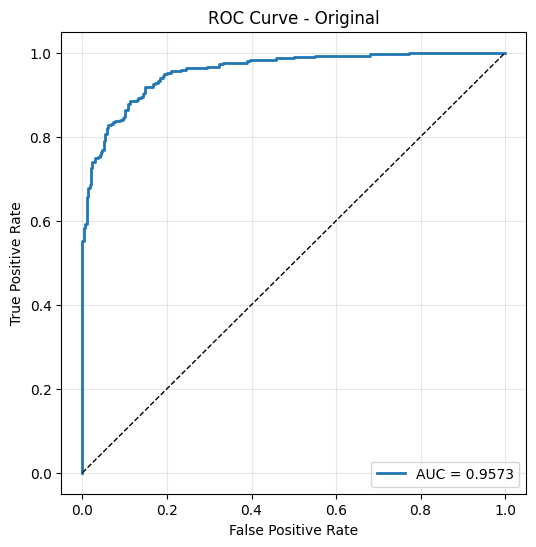

Gaussian Blur: AUC = 0.7043


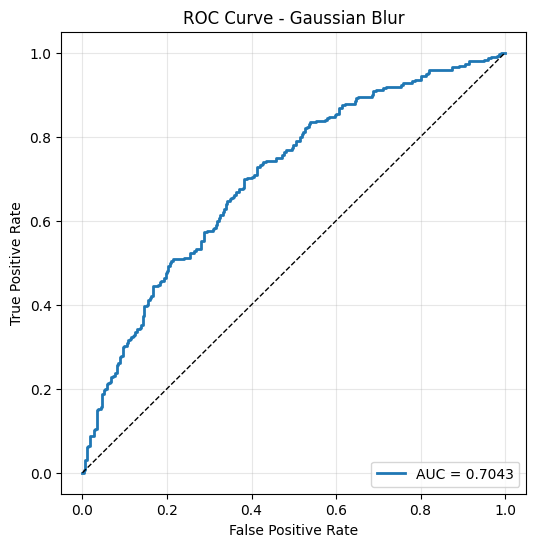

JPEG Compression: AUC = 0.9160


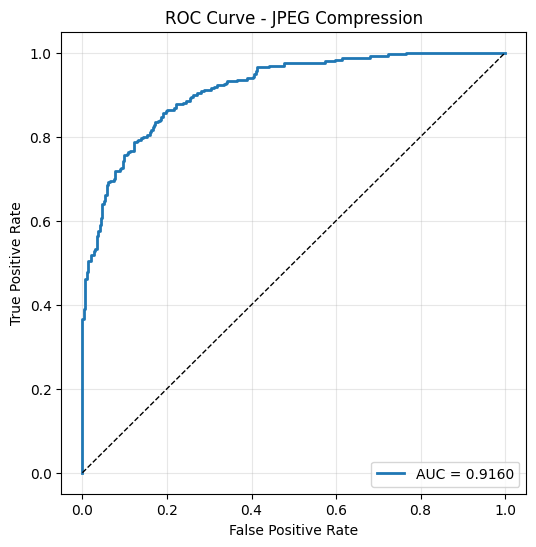

White Gaussian Noise: AUC = 0.5213


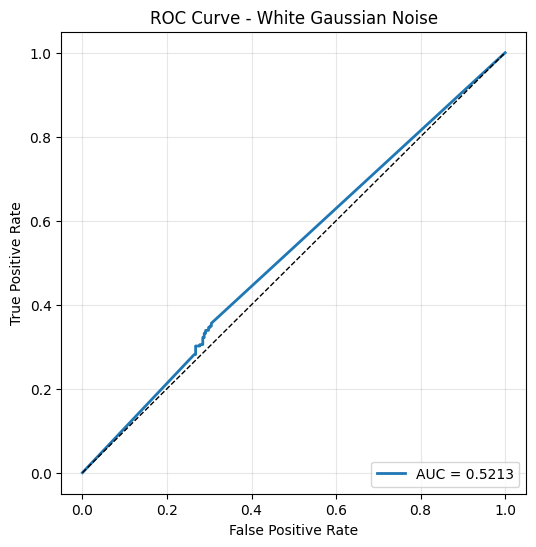

Color Contrast: AUC = 0.8836


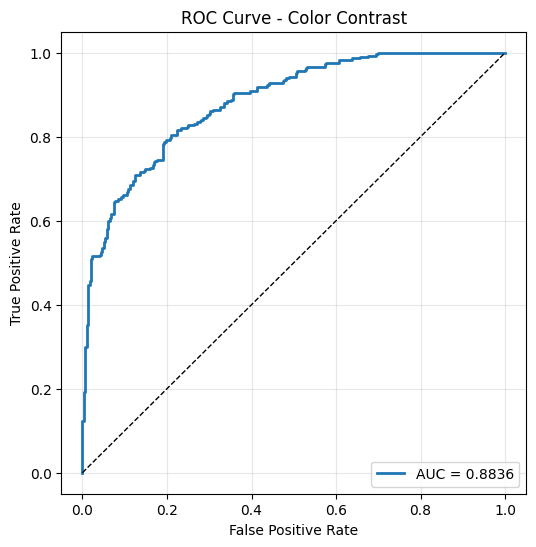

Color Saturation: AUC = 0.9312


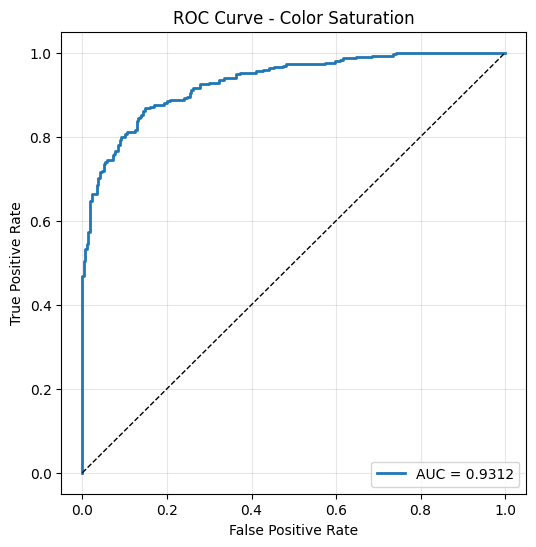

In [102]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

results = []

for perturbation in perturbations:

    dataset = PerturbedDataset(
        root=test_dir,
        transform=test_transform,
        perturbation=perturbation
    )

    test_loader = DataLoader(
        dataset,
        batch_size=32,
        shuffle=False
    )

    y_true = []
    y_score = []

    model.eval()

    with torch.no_grad():

        for images, labels in test_loader:

            images = images.to(device)

            outputs = model(images)

            probs = torch.softmax(outputs, dim=1)[:,1]

            y_true.extend(labels.cpu().numpy())
            y_score.extend(probs.cpu().numpy())

    # Calculate AUC
    auc = roc_auc_score(y_true, y_score)

    # Calculate ROC curve
    fpr, tpr, thresholds = roc_curve(y_true, y_score)

    results.append([perturbation, auc])

    print(f"{perturbation}: AUC = {auc:.4f}")

    # Plot ROC curve
    plt.figure(figsize=(6,6))

    plt.plot(
        fpr,
        tpr,
        linewidth=2,
        label=f"AUC = {auc:.4f}"
    )

    plt.plot(
        [0,1],
        [0,1],
        'k--',
        linewidth=1
    )

    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"ROC Curve - {perturbation}")
    plt.legend(loc="lower right")
    plt.grid(alpha=0.3)

    plt.show()

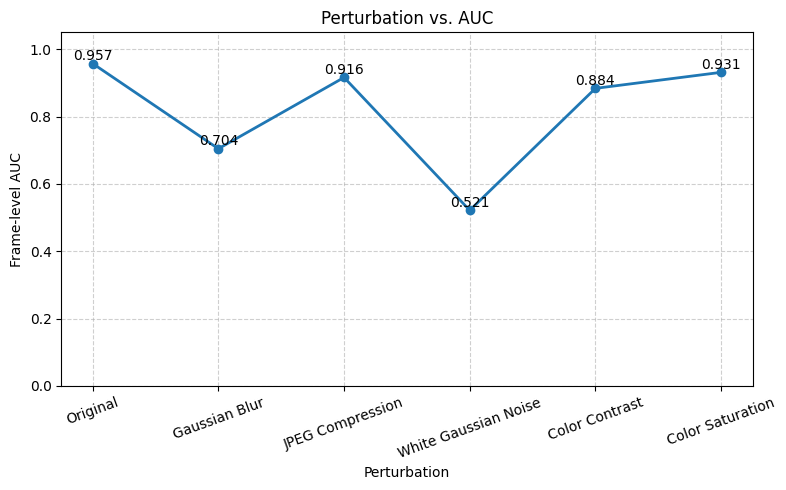

In [104]:
perturbations = [
    "Original",
    "Gaussian Blur",
    "JPEG Compression",
    "White Gaussian Noise",
    "Color Contrast",
    "Color Saturation"
]

auc_scores = [
    0.9573,
    0.7043,
    0.9160,
    0.5213,
    0.8836,
    0.9312
]

plt.figure(figsize=(8,5))
plt.plot(perturbations, auc_scores, marker='o', linewidth=2)

for i, auc in enumerate(auc_scores):
    plt.text(i, auc + 0.01, f"{auc:.3f}", ha='center')

plt.ylim(0,1.05)
plt.xlabel("Perturbation")
plt.ylabel("Frame-level AUC")
plt.title("Perturbation vs. AUC")
plt.grid(True, linestyle="--", alpha=0.6)
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()